In [9]:
%pip install pandas matplotlib seaborn numpy pyarrow fastparquet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import pandas as pd
import os

# -------------------------------
# 1) ตั้งค่าให้ Pandas แสดงผลอ่านง่าย
# -------------------------------
pd.set_option('display.max_columns', None)   # แสดงทุกคอลัมน์
pd.set_option('display.width', 200)          # ความกว้างตาราง
pd.set_option('display.max_colwidth', 20)    # ความกว้างข้อความต่อคอลัมน์
pd.set_option('display.float_format', '{:.4f}'.format)  # ทศนิยมสวย ๆ

# -------------------------------
# 2) path ไปยังไฟล์ CSV
# -------------------------------
file_path = r"C:\punpun\Big data\US-Traffic-Accident-BigData-Analysis\data\raw\US_Accidents_March23.csv"

# -------------------------------
# 3) โหลดข้อมูล
# -------------------------------
if os.path.exists(file_path):
    print("พบไฟล์แล้ว กำลังโหลดข้อมูล...\n")
    
    df = pd.read_csv(file_path)
    
    print(f"โหลดสำเร็จ! จำนวนข้อมูล: {len(df):,} แถว")
    print(f"จำนวนคอลัมน์: {df.shape[1]}\n")
    
    # แสดง 5 แถวแรก แบบเห็นครบทุกคอลัมน์
    display(df.head())
else:
    print(f"ไม่พบไฟล์ที่: {os.path.abspath(file_path)}")


พบไฟล์แล้ว กำลังโหลดข้อมูล...

โหลดสำเร็จ! จำนวนข้อมูล: 7,728,394 แถว
จำนวนคอลัมน์: 46



,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.8651,-84.0587,NaN,NaN,0.0100,Right lane block...,I-70 E,Dayton,Montgomery,OH,45424,US,US/Eastern,KFFO,2016-02-08 05:58:00,36.9000,NaN,91.0000,29.6800,10.0000,Calm,NaN,0.0200,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.9281,-82.8312,NaN,NaN,0.0100,Accident on Bric...,Brice Rd,Reynoldsburg,Franklin,OH,43068-3402,US,US/Eastern,KCMH,2016-02-08 05:51:00,37.9000,NaN,100.0000,29.6500,10.0000,Calm,NaN,0.0000,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.0631,-84.0326,NaN,NaN,0.0100,Accident on OH-3...,State Route 32,Williamsburg,Clermont,OH,45176,US,US/Eastern,KI69,2016-02-08 06:56:00,36.0000,33.3000,100.0000,29.6700,10.0000,SW,3.5000,NaN,Overcast,False,False,False,False,False,False,False,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.7478,-84.2056,NaN,NaN,0.0100,Accident on I-75...,I-75 S,Dayton,Montgomery,OH,45417,US,US/Eastern,KDAY,2016-02-08 07:38:00,35.1000,31.0000,96.0000,29.6400,9.0000,SW,4.6000,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.6278,-84.1884,NaN,NaN,0.0100,Accident on McEw...,Miamisburg Cente...,Dayton,Montgomery,OH,45459,US,US/Eastern,KMGY,2016-02-08 07:53:00,36.0000,33.3000,89.0000,29.6500,6.0000,SW,3.5000,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,True,False,Day,Day,Day,Day


STEP 0: เตรียมของพื้นฐาน

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)


STEP 1: ดูโครงสร้างข้อมูล (Data Overview)

1.1 ขนาดข้อมูล

In [12]:
df.shape


(7728394, 46)

1.2 ชื่อคอลัมน์

In [13]:
df.columns


Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description', 'Street', 'City', 'County', 'State', 'Zipcode', 'Country',
       'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)', 'Precipitation(in)',
       'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop',
       'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight'],
      dtype='str')

1.3 Data type ของแต่ละคอลัมน์

In [14]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     str    
 1   Source                 str    
 2   Severity               int64  
 3   Start_Time             str    
 4   End_Time               str    
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            str    
 11  Street                 str    
 12  City                   str    
 13  County                 str    
 14  State                  str    
 15  Zipcode                str    
 16  Country                str    
 17  Timezone               str    
 18  Airport_Code           str    
 19  Weather_Timestamp      str    
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)            float6

STEP 2: ตรวจ Missing Values

2.1 นับจำนวน missing

In [15]:
missing_count = df.isnull().sum()
missing_count[missing_count > 0].sort_values(ascending=False)


End_Lat                  3402762
End_Lng                  3402762
Precipitation(in)        2203586
Wind_Chill(F)            1999019
Wind_Speed(mph)           571233
Visibility(mi)            177098
Wind_Direction            175206
Humidity(%)               174144
Weather_Condition         173459
Temperature(F)            163853
Pressure(in)              140679
Weather_Timestamp         120228
Sunrise_Sunset             23246
Civil_Twilight             23246
Nautical_Twilight          23246
Astronomical_Twilight      23246
Airport_Code               22635
Street                     10869
Timezone                    7808
Zipcode                     1915
City                         253
Description                    5
dtype: int64

2.2 เปอร์เซ็นต์ missing

In [16]:
missing_percent = (df.isnull().mean() * 100)
missing_percent[missing_percent > 0].sort_values(ascending=False)


End_Lat                 44.0294
End_Lng                 44.0294
Precipitation(in)       28.5129
Wind_Chill(F)           25.8659
Wind_Speed(mph)          7.3914
Visibility(mi)           2.2915
Wind_Direction           2.2670
Humidity(%)              2.2533
Weather_Condition        2.2444
Temperature(F)           2.1201
Pressure(in)             1.8203
Weather_Timestamp        1.5557
Sunrise_Sunset           0.3008
Civil_Twilight           0.3008
Nautical_Twilight        0.3008
Astronomical_Twilight    0.3008
Airport_Code             0.2929
Street                   0.1406
Timezone                 0.1010
Zipcode                  0.0248
City                     0.0033
Description              0.0001
dtype: float64

STEP 3: จัดกลุ่ม Column ตามประเภท “ที่ถูกต้อง”
จาก info():
* datetime = 1
* numerical = int + float
* categorical = str
* boolean = bool

In [17]:
# 1) Datetime columns
date_cols = df.select_dtypes(include=['datetime64']).columns

# 2) Numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# 3) Categorical columns
cat_cols = df.select_dtypes(include=['object', 'string']).columns

# 4) Boolean columns
bool_cols = df.select_dtypes(include=['bool']).columns

print("Datetime:", list(date_cols))
print("Numerical:", len(num_cols))
print("Categorical:", len(cat_cols))
print("Boolean:", len(bool_cols))


Datetime: []
Numerical: 13
Categorical: 20
Boolean: 13


STEP 3.1: แก้ datype ที่ “ยังไม่ถูกต้อง”
จากข้อมูล:
* End_Time → ยังเป็น str
* Weather_Timestamp → ยังเป็น str

In [18]:
df['End_Time'] = pd.to_datetime(df['End_Time'], errors='coerce')
df['Weather_Timestamp'] = pd.to_datetime(df['Weather_Timestamp'], errors='coerce')


อัปเดต date_cols ใหม่

In [19]:
date_cols = df.select_dtypes(include=['datetime64']).columns
date_cols


Index(['End_Time', 'Weather_Timestamp'], dtype='str')

### STEP 4: Numerical EDA

4.1 Summary statistics

In [20]:
pd.set_option('display.max_rows', None)
num_summary = df[num_cols].describe().T
num_summary

,count,mean,std,min,25%,50%,75%,max
Severity,7728394.0000,2.2124,0.4875,1.0000,2.0000,2.0000,2.0000,4.0000
Start_Lat,7728394.0000,36.2012,5.0761,24.5548,33.3996,35.8240,40.0850,49.0022
Start_Lng,7728394.0000,-94.7025,17.3918,-124.6238,-117.2194,-87.7666,-80.3537,-67.1132
End_Lat,4325632.0000,36.2618,5.2729,24.5660,33.4621,36.1835,40.1789,49.0750
End_Lng,4325632.0000,-95.7256,18.1079,-124.5457,-117.7543,-88.0279,-80.2471,-67.1092
Distance(mi),7728394.0000,0.5618,1.7768,0.0000,0.0000,0.0300,0.4640,441.7500
Temperature(F),7564541.0000,61.6633,19.0137,-89.0000,49.0000,64.0000,76.0000,207.0000
Wind_Chill(F),5729375.0000,58.2510,22.3898,-89.0000,43.0000,62.0000,75.0000,207.0000
Humidity(%),7554250.0000,64.8310,22.8210,1.0000,48.0000,67.0000,84.0000,100.0000
Pressure(in),7587715.0000,29.5390,1.0062,0.0000,29.3700,29.8600,30.0300,58.6300


4.2 Variance (หาค่าที่กระจายสูง)

In [21]:
variance = df[num_cols].var().sort_values(ascending=False)
variance


Humidity(%)         520.7966
Wind_Chill(F)       501.3046
Temperature(F)      361.5190
End_Lng             327.8970
Start_Lng           302.4732
Wind_Speed(mph)      29.4304
End_Lat              27.8035
Start_Lat            25.7666
Visibility(mi)        7.2270
Distance(mi)          3.1571
Pressure(in)          1.0124
Severity              0.2377
Precipitation(in)     0.0121
dtype: float64

หา variance เพื่อใช้ตัดสินใจ:
* column ไหนควร scale
* column ไหนอาจมี outlier เยอะ

STEP 4.3 : Outlier Detection (IQR)

In [22]:
important_num_cols = [
    'Severity',
    'Distance(mi)',
    'Temperature(F)',
    'Humidity(%)',
    'Pressure(in)',
    'Visibility(mi)',
    'Wind_Speed(mph)',
    'Precipitation(in)'
]


ฟังก์ชันตรวจ outlier

In [23]:
def iqr_outlier(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
    
    return pd.Series({
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower': lower,
        'Upper': upper,
        'Outlier_Count': outlier_count,
        'Outlier_%': outlier_count / len(df) * 100
    })

outlier_df = df[important_num_cols].apply(lambda x: iqr_outlier(df, x.name)).T
outlier_df


,Q1,Q3,IQR,Lower,Upper,Outlier_Count,Outlier_%
Severity,2.0000,2.0000,0.0000,2.0000,2.0000,1571413.0000,20.3330
Distance(mi),0.0000,0.4640,0.4640,-0.6960,1.1600,963606.0000,12.4684
Temperature(F),49.0000,76.0000,27.0000,8.5000,116.5000,50515.0000,0.6536
Humidity(%),48.0000,84.0000,36.0000,-6.0000,138.0000,0.0000,0.0000
Pressure(in),29.3700,30.0300,0.6600,28.3800,31.0200,443383.0000,5.7371
Visibility(mi),10.0000,10.0000,0.0000,10.0000,10.0000,1481065.0000,19.1639
Wind_Speed(mph),4.6000,10.4000,5.8000,-4.1000,19.1000,210603.0000,2.7251
Precipitation(in),0.0000,0.0000,0.0000,0.0000,0.0000,533090.0000,6.8978


STEP 4.4 : Boxplot (เลือกดูเฉพาะตัวสำคัญ)

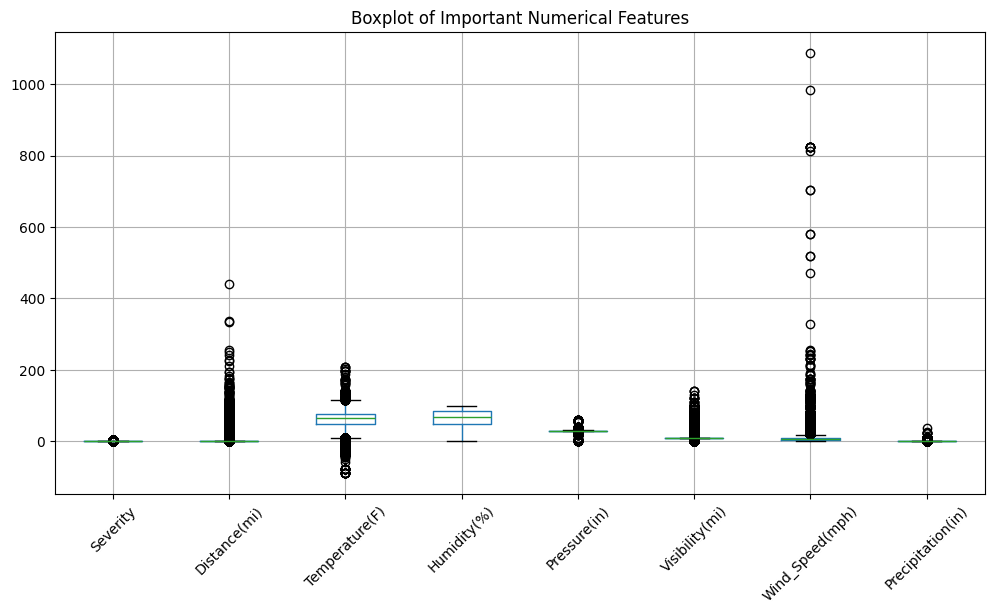

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
df[important_num_cols].boxplot(rot=45)
plt.title("Boxplot of Important Numerical Features")
plt.show()


STEP 4.5 : Distribution (Histogram)

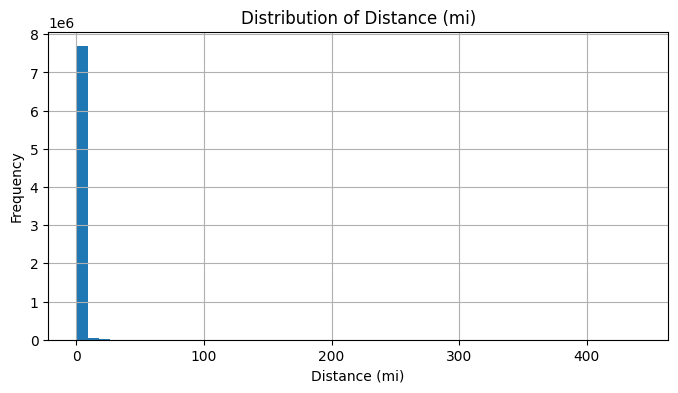

In [25]:
df['Distance(mi)'].hist(bins=50, figsize=(8,4))
plt.title("Distribution of Distance (mi)")
plt.xlabel("Distance (mi)")
plt.ylabel("Frequency")
plt.show()


### STEP 5 : Datetime EDA

5.1 สร้าง time-based features

In [26]:
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')



In [27]:
df['Start_Time'].dtype


dtype('<M8[us]')

In [28]:
df['Start_Hour'] = df['Start_Time'].dt.hour
df['Start_Weekday'] = df['Start_Time'].dt.weekday
df['Start_Month'] = df['Start_Time'].dt.month
df['Is_Weekend'] = df['Start_Weekday'].isin([5,6])


5.2 Duration ของอุบัติเหตุ

In [29]:
df['Accident_Duration_Min'] = (
    df['End_Time'] - df['Start_Time']
).dt.total_seconds() / 60


STEP 6 : Categorical EDA

In [30]:
important_cat_cols = [
    'Severity',
    'State',
    'Weather_Condition',
    'Sunrise_Sunset'
]

for col in important_cat_cols:
    print(f"\n{col}")
    print(df[col].value_counts().head(10))



Severity
Severity
2    6156981
3    1299337
4     204710
1      67366
Name: count, dtype: int64

State
State
CA    1741433
FL     880192
TX     582837
SC     382557
NY     347960
NC     338199
VA     303301
PA     296620
MN     192084
OR     179660
Name: count, dtype: int64

Weather_Condition
Weather_Condition
Fair                2560802
Mostly Cloudy       1016195
Cloudy               817082
Clear                808743
Partly Cloudy        698972
Overcast             382866
Light Rain           352957
Scattered Clouds     204829
Light Snow           128680
Fog                   99238
Name: count, dtype: int64

Sunrise_Sunset
Sunrise_Sunset
Day      5334553
Night    2370595
Name: count, dtype: int64


STEP 7 : Boolean EDA

In [31]:
bool_summary = df[bool_cols].mean().sort_values(ascending=False)
bool_summary


Traffic_Signal    0.1480
Crossing          0.1131
Junction          0.0739
Stop              0.0277
Station           0.0261
Amenity           0.0125
Railway           0.0087
Give_Way          0.0047
No_Exit           0.0025
Traffic_Calming   0.0010
Bump              0.0005
Roundabout        0.0000
Turning_Loop      0.0000
dtype: float64

STEP 8: Correlation

Revised EDA & Correlation–Missing–PCA Pipeline 

STEP 8.1 : ยืนยันสถานะข้อมูลหลัง Data Type Cleaning

In [32]:
# ทุกคอลัมน์อยู่ในชนิดที่ “ควรจะเป็น” ก่อนวิเคราะห์เชิงสถิติ
date_cols = df.select_dtypes(include=['datetime64']).columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object', 'string']).columns
bool_cols = df.select_dtypes(include=['bool']).columns

# แปลง datetime สำคัญ
df['End_Time'] = pd.to_datetime(df['End_Time'], errors='coerce')
df['Weather_Timestamp'] = pd.to_datetime(df['Weather_Timestamp'], errors='coerce')


STEP 8.2 : Datetime Feature Engineering (ทำต่อจากที่มี)

* เป้าหมาย:
แปลงเวลา → ตัวแปรเชิงปริมาณที่ “วิเคราะห์ได้จริง”

In [33]:
df['Start_Hour'] = df['Start_Time'].dt.hour
df['Start_Weekday'] = df['Start_Time'].dt.weekday

df['End_Hour'] = df['End_Time'].dt.hour
df['End_Weekday'] = df['End_Time'].dt.weekday


กำหนดกลุ่ม datetime-derived:


In [34]:
datetime_num_cols = [
    'Start_Hour','Start_Weekday',
    'End_Hour','End_Weekday'
]


STEP 8.3 : คัดเลือก Numeric ที่ “เหมาะกับ Correlation จริง”

In [35]:
numeric_for_analysis = [
    c for c in num_cols
    if df[c].nunique() > 5
    and c not in ['Severity']  # ordinal
]


STEP 8.4 : Distribution Diagnosis (ก่อน Correlation)
* ถ้า skew สูง → Pearson อาจ under-estimate
* จึงต้องดู Pearson + Spearman คู่กัน

In [36]:
df[numeric_for_analysis].describe()


,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in),Start_Hour,Start_Weekday,Start_Month,Accident_Duration_Min
count,7728394.0000,7728394.0000,4325632.0000,4325632.0000,7728394.0000,7564541.0000,5729375.0000,7554250.0000,7587715.0000,7551296.0000,7157161.0000,5524808.0000,6985228.0000,6985228.0000,6985228.0000,6985228.0000
mean,36.2012,-94.7025,36.2618,-95.7256,0.5618,61.6633,58.2510,64.8310,29.5390,9.0904,7.6855,0.0084,12.2678,2.5688,6.7478,426.8765
std,5.0761,17.3918,5.2729,18.1079,1.7768,19.0137,22.3898,22.8210,1.0062,2.6883,5.4250,0.1102,5.4555,1.7968,3.6231,13243.7972
min,24.5548,-124.6238,24.5660,-124.5457,0.0000,-89.0000,-89.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.2167
25%,33.3996,-117.2194,33.4621,-117.7543,0.0000,49.0000,43.0000,48.0000,29.3700,10.0000,4.6000,0.0000,8.0000,1.0000,4.0000,30.0000
50%,35.8240,-87.7666,36.1835,-88.0279,0.0300,64.0000,62.0000,67.0000,29.8600,10.0000,7.0000,0.0000,13.0000,3.0000,7.0000,62.7167
75%,40.0850,-80.3537,40.1789,-80.2471,0.4640,76.0000,75.0000,84.0000,30.0300,10.0000,10.4000,0.0000,17.0000,4.0000,10.0000,122.6333
max,49.0022,-67.1132,49.0750,-67.1092,441.7500,207.0000,207.0000,100.0000,58.6300,140.0000,1087.0000,36.4700,23.0000,6.0000,12.0000,2812939.0000


In [37]:
df[numeric_for_analysis].skew().sort_values(ascending=False)


Precipitation(in)       85.9991
Accident_Duration_Min   52.9009
Distance(mi)            20.3858
Wind_Speed(mph)          8.0495
Visibility(mi)           2.3167
Start_Weekday            0.2044
Start_Lat               -0.0722
Start_Month             -0.1019
Start_Hour              -0.1055
End_Lat                 -0.1582
End_Lng                 -0.3655
Humidity(%)             -0.3948
Start_Lng               -0.4829
Temperature(F)          -0.5137
Wind_Chill(F)           -0.6728
Pressure(in)            -3.6388
dtype: float64

STEP 8.5 : Correlation Analysis (Numeric ↔ Numeric)

8.5.1 Pearson (Linear relationship)

In [38]:
pearson_corr = df[
    numeric_for_analysis + datetime_num_cols
].corr(method='pearson')


8.5.2 Spearman (Monotonic / robust)

In [39]:
spearman_corr = df[
    numeric_for_analysis + datetime_num_cols
].corr(method='spearman')


STEP 8.6 : Missing Value Audit (เริ่มแกะสาเหตุ)
* เป้าหมาย:
ไม่รีบ fill — แต่เข้าใจ กลไกการหายก่อน

8.6.1 Missing rate

In [40]:
missing_rate = df.isna().mean().sort_values(ascending=False)
missing_rate


End_Lng                 0.4403
End_Lat                 0.4403
Precipitation(in)       0.2851
Wind_Chill(F)           0.2587
End_Time                0.0962
Accident_Duration_Min   0.0962
Start_Month             0.0962
End_Hour                0.0962
End_Weekday             0.0962
Start_Weekday           0.0962
Start_Hour              0.0962
Start_Time              0.0962
Wind_Speed(mph)         0.0739
Visibility(mi)          0.0229
Wind_Direction          0.0227
Humidity(%)             0.0225
Weather_Condition       0.0224
Temperature(F)          0.0212
Pressure(in)            0.0182
Weather_Timestamp       0.0156
Nautical_Twilight       0.0030
Astronomical_Twilight   0.0030
Sunrise_Sunset          0.0030
Civil_Twilight          0.0030
Airport_Code            0.0029
Street                  0.0014
Timezone                0.0010
Zipcode                 0.0002
City                    0.0000
Description             0.0000
ID                      0.0000
Country                 0.0000
Distance

8.6.2 Missing Indicator

In [41]:
missing_cols = missing_rate[missing_rate > 0].index

for col in missing_cols:
    df[f'{col}_is_missing'] = df[col].isna().astype(int)


STEP 8.7 : Missing ↔ Numeric / Time Dependency
* เป้าหมาย:
ตรวจว่า missing “เกิดแบบสุ่มจริงไหม”

In [42]:
import pandas as pd

def compute_missing_correlations_fast(df, missing_cols, numeric_for_analysis, datetime_num_cols):
    # รวม columns ที่เป็นตัวแปรต้น (Features) ทั้งหมด
    target_cols = numeric_for_analysis + datetime_num_cols
    
    missing_corr_results = {}
    
    # Optimization: ทำ Ranking ข้อมูลล่วงหน้าแค่ครั้งเดียว 
    # เพราะ Spearman คือ Pearson Correlation ของค่าที่ถูก Rank แล้ว
    # วิธีนี้จะลดเวลาได้มหาศาลหากมี missing_cols หลายตัว
    print("Ranking numeric columns...")
    df_ranked = df[target_cols].rank()
    
    for col in missing_cols:
        ind_col = f"{col}_is_missing"
        if ind_col not in df.columns:
            continue
            
        # Rank ตัว indicator (0/1) 
        ind_ranked = df[ind_col].rank()
        
        # คำนวณ Correlation เฉพาะคู่ (Indicator vs Numeric Columns)
        # ใช้ Pearson บนค่าที่ rank แล้ว = Spearman
        corrs = df_ranked.corrwith(ind_ranked, method='pearson')
        
        # เก็บผลลัพธ์และเรียงลำดับความสำคัญ
        missing_corr_results[col] = corrs.sort_values(key=abs, ascending=False)
        
    return missing_corr_results

In [43]:
# 1. รันฟังก์ชันที่ปรับปรุงใหม่
missing_corr = compute_missing_correlations_fast(df, missing_cols, numeric_for_analysis, datetime_num_cols)

# 2. แสดงผล Top 5 ความสัมพันธ์ที่อาจทำให้เกิดการหายของข้อมูล
for col, correlations in missing_corr.items():
    print(f"\n--- Top correlations for missingness in: {col} ---")
    # กรองเฉพาะที่มีนัยสำคัญ (เช่น > 0.05 หรือ < -0.05)
    top_corr = correlations[correlations.abs() > 0.05].head(5)
    if not top_corr.empty:
        print(top_corr)
    else:
        print("Likely MCAR (Missing Completely At Random) - No strong correlations found.")

Ranking numeric columns...


c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



--- Top correlations for missingness in: End_Lng ---
Distance(mi)            -0.7104
Accident_Duration_Min   -0.5115
Pressure(in)             0.1704
End_Hour                -0.1077
End_Weekday             -0.1074
dtype: float64

--- Top correlations for missingness in: End_Lat ---
Distance(mi)            -0.7104
Accident_Duration_Min   -0.5115
Pressure(in)             0.1704
End_Hour                -0.1077
End_Weekday             -0.1074
dtype: float64

--- Top correlations for missingness in: Precipitation(in) ---
Pressure(in)             0.4389
Accident_Duration_Min   -0.2529
Wind_Chill(F)           -0.2473
Distance(mi)            -0.2387
Wind_Speed(mph)          0.0888
dtype: float64

--- Top correlations for missingness in: Wind_Chill(F) ---
Pressure(in)             0.4002
Precipitation(in)        0.2668
Accident_Duration_Min   -0.2398
Distance(mi)            -0.2370
Temperature(F)           0.1536
dtype: float64

--- Top correlations for missingness in: End_Time ---
Distance(mi) 

STEP 8.8 : Missing ↔ Categorical Context
* เป้าหมาย:
ดู missing ที่ “ขึ้นกับสภาพแวดล้อม”

* ใช้ยืนยันว่า:
missing ไม่ได้สุ่ม
แต่ผูกกับ context (กลางคืน / สภาพอากาศ)

In [44]:
pd.crosstab(
    df['Weather_Condition_is_missing'],
    df['Sunrise_Sunset'],
    normalize='index'
)


Sunrise_Sunset,Day,Night
Weather_Condition_is_missing,,
0,0.6933,0.3067
1,0.6519,0.3481


STEP 8.10 : PCA Candidate Selection (หลังเข้าใจ Missing แล้ว)
* เป้าหมาย:
ใช้ PCA เฉพาะที่สมเหตุสมผล

In [45]:
pca_features = [
    'Temperature(F)',
    'Humidity(%)',
    'Pressure(in)',
    'Visibility(mi)',
    'Wind_Speed(mph)'
]


ตรวจ redundancy:

In [46]:
df[pca_features].corr(method='spearman')


,Temperature(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph)
Temperature(F),1.0000,-0.3306,-0.0036,0.2239,0.0876
Humidity(%),-0.3306,1.0000,0.0575,-0.4654,-0.1984
Pressure(in),-0.0036,0.0575,1.0000,0.0673,-0.0001
Visibility(mi),0.2239,-0.4654,0.0673,1.0000,0.0552
Wind_Speed(mph),0.0876,-0.1984,-0.0001,0.0552,1.0000


Accident_Duration_Min

นี่คือตัวแปร อันตรายที่สุด ใน dataset นี้
เหตุผล:
มันเป็น derived feature
missing มาจาก End_Time
และคุณเห็นแล้วว่ามัน correlate กับหลายอย่าง
สิ่งที่ผมยังไม่รู้:
ค่า 99% อยู่ที่กี่นาที?
max เป็น outlier แบบ “หลักชั่วโมง / วัน / สัปดาห์” ?
distribution มีหางยาวแค่ไหน?

In [ ]:
df[['Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)']].describe()


Distance(mi)

อันนี้ไม่ใช่แค่ outlier
แต่เป็น logical validity
ตอนนี้เรารู้แค่ว่า:
max = 441 miles (ผิดธรรมชาติแน่)
IQR outlier เยอะมาก
แต่ยังไม่รู้:
95 / 99 percentile อยู่ตรงไหน
distribution จริง ๆ เป็น exponential หรือ spike ที่ 0?
📌 ถ้าไม่รู้ → จะ clip แบบมั่วไม่ได้

In [ ]:
df['Distance(mi)'].describe(
    percentiles=[0.5, 0.75, 0.9, 0.95, 0.99, 0.999]
)
df['Distance(mi)'].value_counts().head(10)


Weather numeric sanity

In [ ]:
df.loc[
    df['Accident_Duration_Min'] > 1440,  # มากกว่า 1 วัน
    'Accident_Duration_Min'
].count()

